### 1. 创建一个Tensor  



最常见的创建一个tensor的方法是通过torch.tensor()方法来创建。
这个方法的输入有一个data参数，是必填的参数。它可以是Python里的标量（int，float），也可以是Python里的list、tuple，另外PyTorch也支持用NumPy的ndarray来创建一个tensor。

In [2]:
import numpy as np
import torch

# 1D Tensor
t1 = torch.tensor([1])
print(t1)
print('t1.shape', t1.shape)

# 2D Tensor
t2 = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(t2)

# 3D Tensor
t3 = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
print(t3)

# 从 NumPy 创建 Tensor
arr = np.array([1, 2, 3])
t_np = torch.tensor(arr)
print(t_np)

tensor([1])
t1.shape torch.Size([1])
tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
tensor([1, 2, 3])


*在创建tensor时，PyTorch会根据你传入的数据，自动推断tensor的类型，当然，你也可以自己指定类型。比如：*

In [2]:
import torch

t1 = torch.tensor((2, 2), dtype=torch.float32)
print(t1)

tensor([2., 2.])


##### PyTorch里的数据类型，主要为：

**整数型** torch.uint8、torch.int32、torch.int64。其中torch.int64为默认的整数类型。

**浮点型** torch.float16、torch.bfloat16、 torch.float32、torch.float64，其中torch.float32为默认的浮点数据类型。  
**布尔型** torch.bool

在PyTorch里使用最广泛的就是浮点型tensor。其中torch.float32称为全精度，torch.float16/torch.bfloat16称为半精度。一般情况下模型的训练是在全精度下进行的。如果采用混合精度训练的话，会在某些计算过程中采用半精度计算。混合精度计算会节省显存占用以及提升训练速度。  
PyTorch里没有字符串类型，因为Tensor主要关注于数值计算，并不需要支持字符串类型。

*Bool类型在PyTorch里可以进行高效的索引选择，所以PyTorch支持Bool类型。比如Bool类型tensor进行索引操作示例如下：*

In [3]:
x = torch.tensor([1, 2, 3, 4, 5])
mask = x > 2  # 生成一个布尔掩码
print(mask)  # tensor([False, False,  True,  True,  True])

# 用布尔掩码选出大于 2 的值
filtered_x = x[mask]
print(filtered_x)  # tensor([3, 4, 5])


# 用布尔掩码选出大于 2 的值,并赋值为0
x[mask] = 0
print(x)  # tensor([1, 2, 0, 0, 0])

tensor([False, False,  True,  True,  True])
tensor([3, 4, 5])
tensor([1, 2, 0, 0, 0])


*在创建tensor时，你还可以指定tensor的设备。如果你不指定，默认是在CPU/内存上。如果你想创建一个GPU/显存上的tensor。可以通过把device关键字设定为“cuda”来指定。*

In [4]:
t_gpu = torch.tensor([1, 2, 3], device="cuda")

AssertionError: Torch not compiled with CUDA enabled

*你也可以创建一个用指定值或者随机值填充的tensor。同时你可以指定这个tensor的形状。*

In [ ]:
shape = (2, 3, 3)
rand_tensor = torch.rand(shape)  # 生成一个从[0,1]均匀抽样的tensor。
randn_tensor = torch.randn(shape)  # 生成一个从标准正态分布抽样的tensor。
ones_tensor = torch.ones(shape)  # 生成一个值全为1的tensor。
zeros_tensor = torch.zeros(shape)  # 生成一个值全为0的tensor。
twos_tensor = torch.full(shape, 2)  #  生成一个值全为2的tensor。
t_linspace = torch.linspace(
    0, 10, steps=5
)  # 生成一个一维tensor，包含从0到10的5个均匀间隔的值。
t_arrange = torch.arange(
    0, 10, step=2
)  # 生成一个一维tensor，包含从0到10（不包括10），步长为2的值。
t_logspace = torch.logspace(
    0, 3, steps=4
)  # 生成一个一维tensor，包含从10^0到10^3的4个对数均匀间隔的值。
t_uniform = torch.empty(shape).uniform_(0, 10)  # 生成一个从[0,10)均匀抽样的tensor。
t_randint = torch.randint(0, 10, shape)  # 生成一个从[0,10)均匀抽样的整数tensor。

print(f"rand_tensor:\n{rand_tensor}\n")
print(f"randn_tensor:\n{randn_tensor}\n")
print(f"ones_tensor:\n{ones_tensor}\n")
print(f"zeros_tensor:\n{zeros_tensor}\n")
print(f"twos_tensor:\n{twos_tensor}")
print(f"t_linspace:\n{t_linspace}\n")
print(f"t_arrange:\n{t_arrange}\n")
print(f"t_logspace:\n{t_logspace}\n")
print(f"t_uniform:\n{t_uniform}\n")
print(f"t_randint:\n{t_randint}\n")

rand_tensor:
tensor([[[0.5905, 0.3078, 0.2821],
         [0.0577, 0.7221, 0.1290],
         [0.6889, 0.0791, 0.5445]],

        [[0.1411, 0.8136, 0.6682],
         [0.1418, 0.2903, 0.4037],
         [0.2522, 0.9263, 0.5967]]])

randn_tensor:
tensor([[[ 1.2148,  0.1714, -1.8898],
         [-2.0719, -0.8386, -0.5682],
         [ 0.0303, -0.5037, -2.2419]],

        [[-0.9658, -0.0921,  0.6295],
         [ 0.3074, -1.2480,  2.1984],
         [ 1.2246, -0.5370,  1.3654]]])

ones_tensor:
tensor([[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]])

zeros_tensor:
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])

twos_tensor:
tensor([[[2, 2, 2],
         [2, 2, 2],
         [2, 2, 2]],

        [[2, 2, 2],
         [2, 2, 2],
         [2, 2, 2]]])
t_linspace:
tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000])

t_arrang

### 2. Tensor的属性

通过上边的学习，我们知道一个tensor有几个常用的关键属性，第一个是tensor的形状，第二个是tensor内元素的类型，第三个是tensor的设备。我们可以通过以下方法来查看：

In [9]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### 3. Tensor的操作

#### 3.1 形状变换

在对Tensor进行操作的过程中，我们经常要对tensor进行形状的改变。这里我们介绍常用的一些操作。

In [10]:
x = torch.randn(4, 4)  #  生成一个形状为4x4的随机矩阵。
print(f"Original x:\n{x}\n")
x = x.reshape(2, 8)  # 通过reshape操作，可以将4x4的矩阵改变为2x8的矩阵。
print(f"Reshaped x (2x8):\n{x}\n")

Original x:
tensor([[ 0.3168, -0.2802,  0.8809,  0.5463],
        [ 0.2987, -0.5333, -0.1561,  0.8969],
        [ 1.5764, -0.6563,  0.3547, -0.0760],
        [-1.6732, -0.5545,  1.2655, -0.2232]])

Reshaped x (2x8):
tensor([[ 0.3168, -0.2802,  0.8809,  0.5463,  0.2987, -0.5333, -0.1561,  0.8969],
        [ 1.5764, -0.6563,  0.3547, -0.0760, -1.6732, -0.5545,  1.2655, -0.2232]])



*你可以通过permute函数来交换tensor的维度（转置），需要注意的是它的作用与reshape不同，reshape是按元素顺序重新组织维度，permute会改变元素的顺序。*

In [11]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
x_reshape = x.reshape(3, 2)
x_transpose = x.permute(
    1, 0
)  # 交换第0个和第1个维度。对于二维矩阵就是行列互换，进行转置。
print("reshape:", x_reshape)
print("permute:", x_transpose)

reshape: tensor([[1, 2],
        [3, 4],
        [5, 6]])
permute: tensor([[1, 4],
        [2, 5],
        [3, 6]])


permute 接受的是维度顺序列表/序列，含义是“把原张量的各个维度按照给定顺序重新排列”。

对 x = torch.tensor([[1, 2, 3], [4, 5, 6]])（形状是 (2, 3)）：

- x.permute(1, 0) 中的参数 (1, 0) 表示：
    - 新的第 0 维使用原来的第 1 维
    - 新的第 1 维使用原来的第 0 维
- 结果形状从 (2, 3) 变为 (3, 2)，等价于二维矩阵的转置。  

更一般地：

- 如果张量形状是 (d0, d1, d2, ...)，调用 x.permute(a, b, c, ...) 要求参数个数与维度数一致，且每个维度索引只出现一次。
返回的新张量形状为 (d_a, d_b, d_c, ...)，数据会按新顺序重新排列。

In [12]:
x = torch.arange(12).reshape(2, 2, 3)  # 形状 (2, 2, 3)
# x =
# [[[ 0,  1,  2],
#   [ 3,  4,  5]],
#  [[ 6,  7,  8],
#   [ 9, 10, 11]]]

y = x.permute(2, 0, 1)  # 参数顺序 (2, 0, 1)：新形状 (3, 2, 2)
print(y)
# 对应元素被按新维度顺序重新组织
# 每个维度按照之前的步长取对应位置的元素即可

tensor([[[ 0,  3],
         [ 6,  9]],

        [[ 1,  4],
         [ 7, 10]],

        [[ 2,  5],
         [ 8, 11]]])


*对于二维tensor，你可以调用tensor.t()方法进行转置操作。 有时，需要扩展tensor的维度，可以使用unsqueeze函数。*

In [15]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
# 转置
x_t = x.t()
print(x_t)
# 扩展第0维
x_0 = x.unsqueeze(0)
print(x_0.shape, x_0)
# 扩展第1维
x_1 = x.unsqueeze(1)
print(x_1.shape, x_1)
# 扩展第2维
x_2 = x.unsqueeze(2)
print(x_2.shape, x_2)

tensor([[1, 4],
        [2, 5],
        [3, 6]])
torch.Size([1, 2, 3]) tensor([[[1, 2, 3],
         [4, 5, 6]]])
torch.Size([2, 1, 3]) tensor([[[1, 2, 3]],

        [[4, 5, 6]]])
torch.Size([2, 3, 1]) tensor([[[1],
         [2],
         [3]],

        [[4],
         [5],
         [6]]])


*你可以使用tensor的squeeze方法来缩减tensor的大小为1的维度。你可以指定需要缩减的维度索引，如果不指定，则会缩减所有大小为1的维度。*

In [14]:
x = torch.ones((1, 1, 3))
print(x.shape, x)
y = x.squeeze(dim=0)
print(y.shape, y)
z = x.squeeze()
print(z.shape, z)

torch.Size([1, 1, 3]) tensor([[[1., 1., 1.]]])
torch.Size([1, 3]) tensor([[1., 1., 1.]])
torch.Size([3]) tensor([1., 1., 1.])


#### 3.2 数学运算

In [16]:
a = torch.ones((2, 3))
b = torch.ones((2, 3))

print(a + b)  # 加法
print(a - b)  # 减法
print(a * b)  # 逐元素乘法
print(a / b)  # 逐元素除法
print(a @ b.t())  # 矩阵乘法

tensor([[2., 2., 2.],
        [2., 2., 2.]])
tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[3., 3.],
        [3., 3.]])


#### 3.3 统计函数

一个tensor中包含多个元素，对这些元素可以进行统计操作。  
比如通过tensor.sum()求和，通过tensor.mean()求均值，通过tensor.std()求标准差，通过tensor.min()求最小值等。

![屏幕截图 2025-12-23 174254.png](<attachment:屏幕截图 2025-12-23 174254.png>)
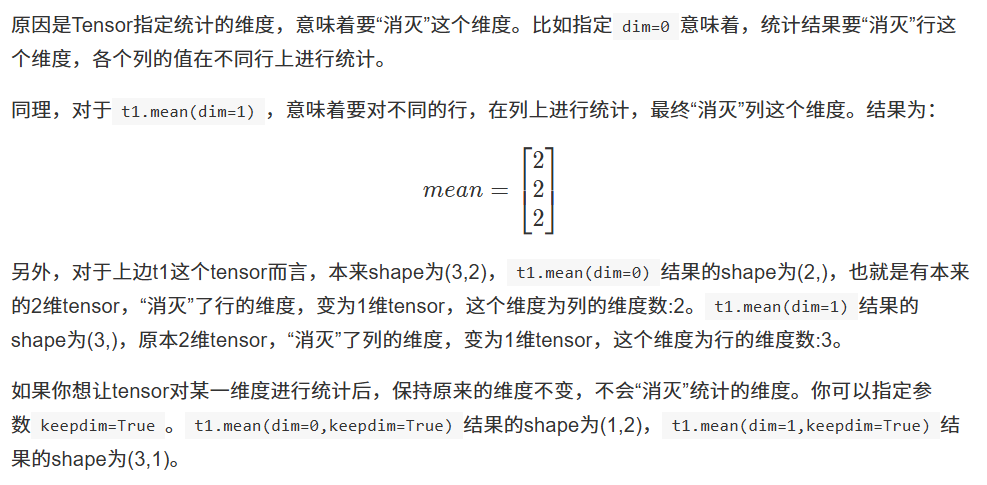
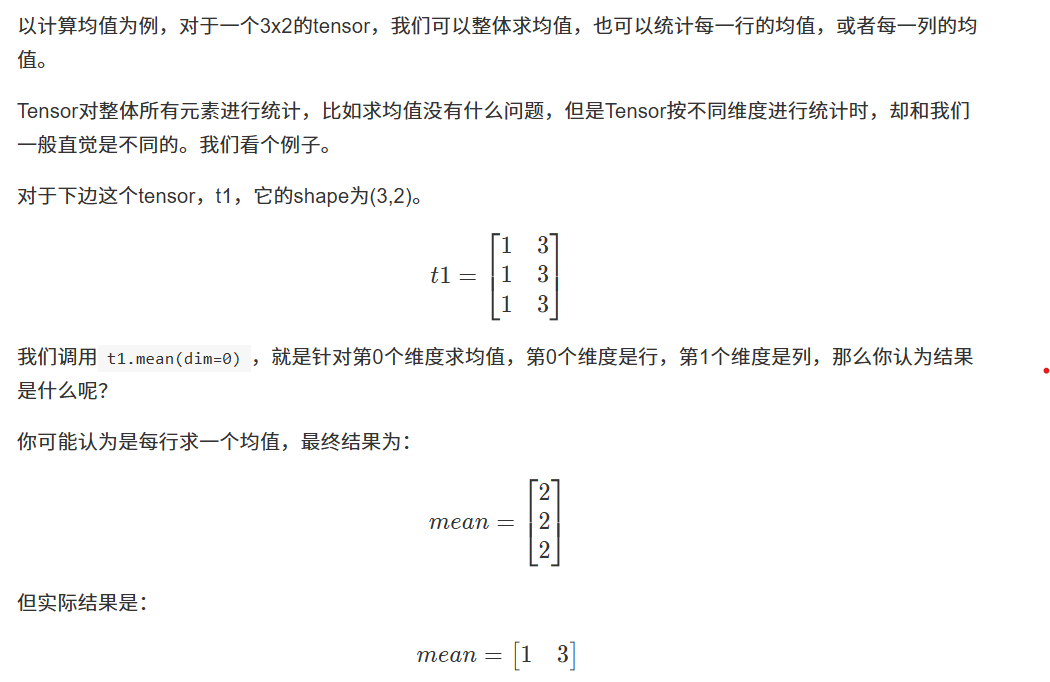

*具体代码如下：*

In [17]:
import torch

t = torch.tensor([[1.0, 3.0], [1.0, 3.0], [1.0, 3.0]])

mean = t.mean()
print("mean:", mean)

mean = t.mean(dim=0)
print("mean on dim 0:", mean)

mean = t.mean(dim=0, keepdim=True)
print("keepdim:", mean)

mean: tensor(2.)
mean on dim 0: tensor([1., 3.])
keepdim: tensor([[1., 3.]])


In [31]:
shape = (3, 2, 2)
t = torch.randint(0, 10, shape, dtype=torch.float32)
print("Original tensor:\n", t)

mean = t.mean()
print("mean all elements:", mean)

mean_dim0 = t.mean(dim=0)
print("mean dim 0:", mean_dim0, "mean dim0 shape:", mean_dim0.shape)

mean_dim1 = t.mean(dim=1)
print("mean dim 1:", mean_dim1, "mean dim1 shape:", mean_dim1.shape)

mean_dim2 = t.mean(dim=2, keepdim=True)
print("mean dim 2:", mean_dim2, "mean dim2 shape:", mean_dim2.shape)

Original tensor:
 tensor([[[6., 1.],
         [2., 0.]],

        [[8., 8.],
         [7., 5.]],

        [[1., 9.],
         [9., 2.]]])
mean all elements: tensor(4.8333)
mean dim 0: tensor([[5.0000, 6.0000],
        [6.0000, 2.3333]]) mean dim0 shape: torch.Size([2, 2])
mean dim 1: tensor([[4.0000, 0.5000],
        [7.5000, 6.5000],
        [5.0000, 5.5000]]) mean dim1 shape: torch.Size([3, 2])
mean dim 2: tensor([[[3.5000],
         [1.0000]],

        [[8.0000],
         [6.0000]],

        [[5.0000],
         [5.5000]]]) mean dim2 shape: torch.Size([3, 2, 1])


#### 3.4 索引和切片

和python里的序列数据类似，tensor也支持索引和切片操作。

In [32]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(x[0, 1])  # 访问第一行第二个元素
print(x[:, 1])  # 访问第二列
print(x[1, :])  # 访问第二行
print(x[:, :2])  # 访问前两列

tensor(2)
tensor([2, 5])
tensor([4, 5, 6])
tensor([[1, 2],
        [4, 5]])


#### 3.5 广播机制

[广播机制](https://www.rethink.fun/chapter6/Tensor.html)